In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch

from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.callbacks import EvalCallback

from src.data_processor import add_technical_indicators, extract_regimes
from src.environment import OptimalExecutionEnv

In [2]:
df_raw = pd.read_csv("data/BTCUSDT_1h_FINAL.csv")
df_raw['Open_Time'] = pd.to_datetime(df_raw['Open_Time'])
print(f"Loaded: {len(df_raw):,} rows | {df_raw['Open_Time'].min()} → {df_raw['Open_Time'].max()}")

df_enriched = add_technical_indicators(df_raw)
df_final, transmat, model, regime_stats = extract_regimes(df_enriched)
print("\nTransition matrix:")
print(np.round(transmat, 4))

Loaded: 64,189 rows | 2019-01-01 00:00:00 → 2026-04-30 23:00:00


Model is not converging.  Current: 578633.4478265167 is not greater than 578641.923285059. Delta is -8.47545854235068


  Regime 0 (Bearish): μ_ret=0.00002  μ_vol=0.01209  n=9,568 (14.9%)
  Regime 1 (Neutral): μ_ret=0.00008  μ_vol=0.00591  n=26,561 (41.4%)
  Regime 2 (Bullish): μ_ret=0.00008  μ_vol=0.00298  n=28,033 (43.7%)

Transition matrix (Chapman–Kolmogorov A):
[[9.697e-01 2.950e-02 8.000e-04]
 [9.000e-03 9.717e-01 1.920e-02]
 [1.900e-03 1.650e-02 9.816e-01]]

Transition matrix:
[[9.697e-01 2.950e-02 8.000e-04]
 [9.000e-03 9.717e-01 1.920e-02]
 [1.900e-03 1.650e-02 9.816e-01]]


In [3]:
split_idx = int(len(df_final) * 0.8)
train_df  = df_final.iloc[:split_idx].reset_index(drop=True)
test_df   = df_final.iloc[split_idx:].reset_index(drop=True)

print(f"Train: {len(train_df):,} rows  ({train_df['Open_Time'].min()} → {train_df['Open_Time'].max()})")
print(f"Test:  {len(test_df):,} rows  ({test_df['Open_Time'].min()} → {test_df['Open_Time'].max()})")

Train: 51,329 rows  (2019-01-02 03:00:00 → 2024-11-12 06:00:00)
Test:  12,833 rows  (2024-11-12 07:00:00 → 2026-04-30 23:00:00)


In [4]:
T = 24
TOTAL_TO_SELL = 10.0

def make_env(df, transmat, T, total_to_sell):
    def _init():
        env = OptimalExecutionEnv(df, transmat, total_to_sell=total_to_sell, T=T)
        return Monitor(env)
    return _init


train_env = DummyVecEnv([make_env(train_df, transmat, T, TOTAL_TO_SELL)])
train_env = VecNormalize(train_env, norm_obs=True, norm_reward=True, clip_obs=10.0)

eval_vec = DummyVecEnv([make_env(test_df, transmat, T, TOTAL_TO_SELL)])
eval_vec = VecNormalize(eval_vec, norm_obs=True, norm_reward=False, training=False, clip_obs=10.0)

model = PPO(
    "MlpPolicy", train_env,
    learning_rate=3e-4, n_steps=2048, batch_size=256, n_epochs=10,
    gamma=0.99, gae_lambda=0.95, clip_range=0.2, ent_coef=0.01,
    policy_kwargs=dict(net_arch=[256, 256, 128]),
    verbose=1,
)

eval_cb = EvalCallback(eval_vec, best_model_save_path="./models/",
                       eval_freq=10_000, n_eval_episodes=5,
                       deterministic=True, verbose=0)

print("Entraînement en cours…")

model = PPO.load("models/ppo_ck_impact_v1.zip", env=train_env)
train_env = VecNormalize.load("models/vec_normalize_impact.pkl", train_env)
print("Modèle chargé avec succès !")

Using cpu device
Entraînement en cours…
Modèle chargé avec succès !


In [5]:
def run_episode(strategy, env, model=None, vec_norm=None):
    obs, _ = env.reset()
    done, step = False, 0
    history = {'price': [], 'amount': [], 'inventory': [], 'regime': [], 'revenue': []}
    while not done:
        if strategy == 'drl':
            obs_n = vec_norm.normalize_obs(obs.reshape(1, -1))
            action, _ = model.predict(obs_n, deterministic=True)
        elif strategy == 'twap':
            frac   = 1.0 / env.T
            action = np.array([np.clip(frac / max(env.inventory / env.initial_inventory, 1e-6), 0, 1)])
        elif strategy == 'vwap':
            action = np.array([1.0 / max(env.T - step, 1)])
        obs, reward, done, _, info = env.step(action)
        history['price'].append(info['price'])
        history['amount'].append(info['amount'])
        history['inventory'].append(info['inventory'])
        history['regime'].append(int(round(float(obs[5]))))
        history['revenue'].append(info['revenue'])
        step += 1
    history['total_revenue'] = sum(history['revenue'])
    return history


def test_agent(model, vec_norm, test_df, transmat, n_episodes=5):
    REGIME_COLORS = {0: '#e74c3c', 1: '#f39c12', 2: '#2ecc71'}
    REGIME_LABELS = {0: 'Bearish', 1: 'Neutral', 2: 'Bullish'}
    strategies    = ['drl', 'twap', 'vwap']
    all_revenues  = {s: [] for s in strategies}

    for ep in range(n_episodes):
        seed = ep * 7
        envs = {s: OptimalExecutionEnv(test_df, transmat, total_to_sell=10.0, T=24)
                for s in strategies}
        envs['drl'].reset(seed=seed)
        tick = envs['drl'].start_tick
        for s, env in envs.items():
            env.start_tick = tick; env.current_step = 0; env.inventory = env.initial_inventory

        for s in strategies:
            h = run_episode(s, envs[s], model=model, vec_norm=vec_norm)
            all_revenues[s].append(h['total_revenue'])

        print(f"Ép.{ep+1}: DRL={all_revenues['drl'][-1]:>12,.0f}  "
              f"TWAP={all_revenues['twap'][-1]:>12,.0f}  "
              f"VWAP={all_revenues['vwap'][-1]:>12,.0f} USDT")
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    colors = ['#3498db', '#e67e22', '#9b59b6']
    data = [all_revenues[s] for s in strategies]
    bp   = axes[0].boxplot(data, patch_artist=True, widths=0.4,
                           medianprops=dict(color='white', linewidth=2))
    for patch, c in zip(bp['boxes'], colors):
        patch.set_facecolor(c); patch.set_alpha(0.8)
    axes[0].set_xticklabels(['DRL', 'TWAP', 'VWAP'])
    axes[0].set_title("Distribution des revenus", fontweight='bold')
    axes[0].set_ylabel("Revenu Total (USDT)")
    axes[0].spines[['top', 'right']].set_visible(False)
    x = range(1, n_episodes + 1)
    for s, c in zip(strategies, colors):
        axes[1].plot(x, all_revenues[s], marker='o', label=s.upper(), color=c, lw=2)
    axes[1].set_title("Revenu par épisode (USDT réels)", fontweight='bold')
    axes[1].set_xlabel("Épisode"); axes[1].set_ylabel("USDT")
    axes[1].legend(); axes[1].spines[['top', 'right']].set_visible(False)

    plt.suptitle("Performance de l'Agent — DRL vs TWAP vs VWAP", fontweight='bold')
    plt.tight_layout()
    plt.show()


Évaluation de l'agent
Ép.1: DRL=   1,065,989  TWAP=     695,307  VWAP=     984,247 USDT
Ép.2: DRL=   1,106,718  TWAP=   1,086,444  VWAP=     878,039 USDT
Ép.3: DRL=     833,101  TWAP=   1,042,272  VWAP=     668,061 USDT
Ép.4: DRL=     901,406  TWAP=     833,732  VWAP=   1,076,050 USDT
Ép.5: DRL=     702,592  TWAP=   1,034,390  VWAP=   1,134,579 USDT
Ép.6: DRL=   1,039,417  TWAP=   1,193,096  VWAP=     975,857 USDT
Ép.7: DRL=     873,278  TWAP=     702,470  VWAP=     842,959 USDT
Ép.8: DRL=   1,078,843  TWAP=     983,914  VWAP=     642,060 USDT
Ép.9: DRL=     917,915  TWAP=   1,054,912  VWAP=     653,594 USDT
Ép.10: DRL=   1,103,366  TWAP=   1,046,424  VWAP=   1,007,874 USDT
Ép.11: DRL=   1,050,767  TWAP=     968,993  VWAP=     709,344 USDT
Ép.12: DRL=     941,292  TWAP=     883,219  VWAP=     824,827 USDT
Ép.13: DRL=     902,145  TWAP=   1,106,252  VWAP=   1,094,408 USDT
Ép.14: DRL=     834,376  TWAP=     827,397  VWAP=   1,019,867 USDT
Ép.15: DRL=     666,757  TWAP=     678,293  VWAP

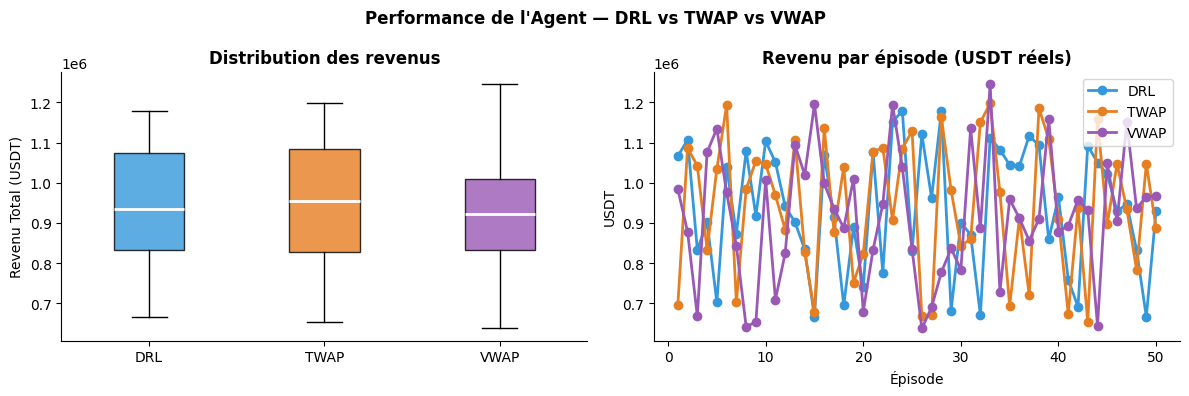

In [6]:
print("\nÉvaluation de l'agent")
test_agent(model, eval_vec, test_df, transmat, n_episodes=50)